# Connotation Frame Analysis

We apply the **Riveter** framework ([Antoniak et al., 2023](http://maartensap.com/pdfs/antoniak2023riveter.pdf)) built on the Connotation Frames lexicon of [Sap et al. (2017)](https://arxiv.org/abs/1702.01151) to measure power, agency, and sentiment dynamics in our opium literature corpus.

First we load the lexicons:

In [1]:
import pandas as pd
import numpy as np
import spacy

nlp = spacy.load("en_core_web_sm")

/Users/ngocdoan/opt/anaconda3/envs/history39/lib/python3.9/site-packages/spacy/cli/info.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/ngocdoan/opt/anaconda3/envs/history39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Sentiment Lexicon (Rashkin et al. 2016)
cf_df = pd.read_csv('../../frameworks/connotation_frame/rashkin-lexicon/full_frame_info.txt', sep='\t')
sentiment_dict = cf_df.set_index('verb')[['writer_perspective(a)', 'writer_perspective(t)']].to_dict('index')
list(sentiment_dict.items())[:10]

[('have',
  {'writer_perspective(a)': 0.333333333333,
   'writer_perspective(t)': 0.366666666667}),
 ('say',
  {'writer_perspective(a)': 0.166666666667, 'writer_perspective(t)': 0.0}),
 ('make',
  {'writer_perspective(a)': 0.1, 'writer_perspective(t)': -0.0666666666667}),
 ('take', {'writer_perspective(a)': 0.6, 'writer_perspective(t)': 0.5}),
 ('go',
  {'writer_perspective(a)': 0.133333333333,
   'writer_perspective(t)': 0.0666666666667}),
 ('come',
  {'writer_perspective(a)': 0.3, 'writer_perspective(t)': 0.0666666666667}),
 ('get',
  {'writer_perspective(a)': 0.333333333333, 'writer_perspective(t)': 0.2}),
 ('know',
  {'writer_perspective(a)': 0.5, 'writer_perspective(t)': 0.366666666667}),
 ('give',
  {'writer_perspective(a)': 0.4, 'writer_perspective(t)': 0.233333333333}),
 ('include',
  {'writer_perspective(a)': 0.266666666667,
   'writer_perspective(t)': 0.433333333333})]

In [3]:
# Agency and Power Lexicon (Sap et al. 2017)
ap_df = pd.read_csv('../../frameworks/connotation_frame/sap-lexicon/agency_power.csv')
ap_df_combined = ap_df.groupby('verb', as_index=False).agg(lambda x: x.dropna().iloc[0] if not x.dropna().empty else np.nan) # combine dup rows
ap_dict = ap_df_combined.set_index('verb').to_dict('index')
list(ap_dict.items())[:10]

[('abandon', {'agency': 'agency_pos', 'power': 'power_agent'}),
 ('abolish', {'agency': 'agency_pos', 'power': 'power_agent'}),
 ('absorb', {'agency': 'agency_pos', 'power': 'power_agent'}),
 ('abuse', {'agency': 'agency_pos', 'power': 'power_agent'}),
 ('accelerate', {'agency': 'agency_pos', 'power': 'power_agent'}),
 ('accept', {'agency': 'agency_neg', 'power': 'power_agent'}),
 ('access', {'agency': 'agency_equal', 'power': 'power_agent'}),
 ('accommodate', {'agency': 'agency_pos', 'power': 'power_equal'}),
 ('accompany', {'agency': 'agency_equal', 'power': 'power_theme'}),
 ('accomplish', {'agency': 'agency_pos', 'power': 'power_equal'})]

Score mapping logic according to lexicon labels:

The 2016 Rashkin paper (Sentiment) asked crowdsourced workers to rate sentiment on a sliding scale (e.g., from -3 to 3, which was then normalized), yielding continuous probabilities like 0.33. The 2017 Sap paper (Power/Agency) found that annotators struggled to rate intensity of power, so they simplified the task to a categorical choice: "Does this verb give power? Yes (1), No (-1), Neutral (0)".
Since both metrics are ultimately bounded between [-1.0, 1.0], averaging them out over hundreds of occurrences works perfectly. A t-test handles both continuous and discrete inputs without issue.


In [5]:
def get_agency_score(agency_label):
    if not isinstance(agency_label, str): return np.nan
    if agency_label == 'agency_pos': return 1.0
    if agency_label == 'agency_neg': return -1.0
    if agency_label == 'agency_equal': return 0.0
    return np.nan

def get_power_score(power_label, role):
    if not isinstance(power_label, str): return np.nan
    
    # If the verb empowers the Agent (Subject)
    if power_label == 'power_agent':
        return 1.0 if role == 'agent' else -1.0
        
    # If the verb empowers the Theme (Object)
    elif power_label == 'power_theme':
        return -1.0 if role == 'agent' else 1.0
        
    # If power is equal/neutral
    elif power_label == 'power_equal':
        return 0.0
        
    return np.nan

In [6]:
# reusing gendered vocabs from gender extraction
MALE_VOCAB = {
    'he', 'him', 'his', 'man', 'boy', 'gentleman',
    'father', 'brother', 'husband', 'uncle',
    'son', 'master', 'sir', 'lord', 'clergyman',
    'mr', 'mister', 'colonel', 'major', 'captain'
}

FEMALE_VOCAB = {
    'she', 'her', 'hers', 'woman', 'girl', 'lady',
    'mother', 'sister', 'wife', 'aunt',
    'daughter', 'mistress', 'widow', 'governess', 
    'nurse', 'mrs', 'miss', 'madam', 'madame'
}

Connotation scoring logic:
1. Find the Match: Find a target (gendered) word (e.g., "she").
2. Find the Verb: Use a dependency parser to find the verb acting on "she" (e.g., "yield").
3. Determine the Role: Is "she" the Subject (Agent) or Object (Theme) of "yield"?
4. Look up the Score: If "she" is the Subject, look up the agency score and power (agent) score for "yield" in the Sap et al. lexicon.
Example: "yield" has an Agency score of -1 and a Power score of -1.
5. Average it Out: If "she" appears 100 times in the dataset, sum up all those 1, 0, and -1 scores and divide by 100.

Note that we're doing this on the full snippets, not just within the sentence with the occurance of the opium keyword itself. We're basically looking at _gendered actions in the vicinity of opium_, which captures the general "ambiance" and characterization of men and women in opium-related scenes. Even if a woman isn't actively smoking opium, the fact that she is framed as a passive theme (e.g. "left", "made", "suffered") while opium is in the room tells us a lot about the literary tropes of these scenes. We have much more context* this way, though keep in mind it might also be a bit noisy (refering to generic actions that are not specifically related to opium)

*also meaning more data - since this framework is also based off *dependency parsing*, and as we've observed in gender extraction earlier, it's not always the case that we can parse gender attribute with this method in the immediate sentence containing opium keywords (which we solved by referring to the broader context) -> here we also refer to the broader context (the whole snippet) for our inference

In [7]:
def calculate_connotations(row):
    text = str(row['Snippet'])
    target_gender = row['Assigned_Gender']
    
    # Skip if not Male or Female
    if target_gender not in ['Male', 'Female']:
        return pd.Series({'Agency': np.nan, 'Power': np.nan, 'Sentiment': np.nan})
        
    doc = nlp(text)
    vocab = FEMALE_VOCAB if target_gender == 'Female' else MALE_VOCAB
    
    agency_scores = []
    power_scores = []
    sentiment_scores = []
    
    for token in doc:
        # Check if the word belongs to the target gender
        if token.text.lower() in vocab:
            head = token.head
            
            # Check if the word is attached to a verb
            if head.pos_ == 'VERB':
                verb = head.lemma_.lower()
                
                # Determine role based on dependency
                role = None
                if token.dep_ == 'nsubj':
                    role = 'agent'
                elif token.dep_ in ['nsubjpass', 'dobj', 'pobj', 'dative']:
                    role = 'theme'
                
                if role == 'agent':
                    # 1. Sentiment Lookup
                    if verb in sentiment_dict:
                        sentiment_scores.append(sentiment_dict[verb]['writer_perspective(a)'])
                        
                    # 2. Agency & Power Lookup
                    if verb in ap_dict:
                        agency_label = ap_dict[verb].get('agency')
                        power_label = ap_dict[verb].get('power')
                        
                        agency_scores.append(get_agency_score(agency_label))
                        power_scores.append(get_power_score(power_label, role='agent'))

                elif role == 'theme':
                    # 1. Sentiment Lookup
                    if verb in sentiment_dict:
                        sentiment_scores.append(sentiment_dict[verb]['writer_perspective(t)'])
                        
                    # 2. Power Lookup (Objects/Passive subjects rarely get agency in this framework)
                    if verb in ap_dict:
                        power_label = ap_dict[verb].get('power')
                        power_scores.append(get_power_score(power_label, role='theme'))

    # Drop NaNs from lists before averaging
    agency_scores = [s for s in agency_scores if pd.notna(s)]
    power_scores = [s for s in power_scores if pd.notna(s)]
    sentiment_scores = [s for s in sentiment_scores if pd.notna(s)]

    # Return the averages for this snippet
    return pd.Series({
        'Agency': np.mean(agency_scores) if agency_scores else np.nan,
        'Power': np.mean(power_scores) if power_scores else np.nan,
        'Sentiment': np.mean(sentiment_scores) if sentiment_scores else np.nan
    })


In [8]:
df_all = pd.read_csv('../../data/snippets/total_snippets_with_gender.csv')

# Keep only snippets where we are confident about the gender
# 'Male' and 'Female' are directly resolved; we exclude Unknown / Dialogue rows
df = df_all[df_all['Assigned_Gender'].isin(['Male', 'Female'])].copy()
df = df.reset_index(drop=True)

print(f"Total gendered snippets: {len(df)}")
print(df['Assigned_Gender'].value_counts())

Total gendered snippets: 3697
Assigned_Gender
Male      2713
Female     984
Name: count, dtype: int64


In [9]:
from tqdm import tqdm
tqdm.pandas()
df[['Agency', 'Power', 'Sentiment']] = df.progress_apply(calculate_connotations, axis=1)

100%|██████████| 3697/3697 [02:35<00:00, 23.76it/s]


In [10]:
# Filter out snippets that didn't have any CF verbs
analysis_df = df.dropna(subset=['Agency', 'Power', 'Sentiment'], how='all')

# Print the final averages
print("\n=== CONNOTATION FRAME AVERAGES BY GENDER ===")
print(analysis_df.groupby('Assigned_Gender')[['Agency', 'Power', 'Sentiment']].mean())


=== CONNOTATION FRAME AVERAGES BY GENDER ===
                   Agency     Power  Sentiment
Assigned_Gender                               
Female           0.416227  0.112297   0.276373
Male             0.486742  0.169289   0.264776


The numbers look close at first glance (e.g., 0.41 vs 0.48), but in Connotation Frames, a gap of 0.05 to 0.07 is actually quite substantial. Because scores are bounded between -1 and 1—and are heavily diluted by hundreds of neutral verbs (scored 0). Bias in literature is subtle but systemic.

Let's check the statistical significance of this gap:

=== STATISTICAL SIGNIFICANCE (T-TESTS) ===
Agency: p-value = 0.0008 -> *** SIGNIFICANT ***
Power: p-value = 0.0056 -> *** SIGNIFICANT ***
Sentiment: p-value = 0.0113 -> *** SIGNIFICANT ***


/var/folders/2j/w898mtss6bncgwx8ldvsq6yr0000gn/T/ipykernel_2279/3985600041.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/2j/w898mtss6bncgwx8ldvsq6yr0000gn/T/ipykernel_2279/3985600041.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/2j/w898mtss6bncgwx8ldvsq6yr0000gn/T/ipykernel_2279/3985600041.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


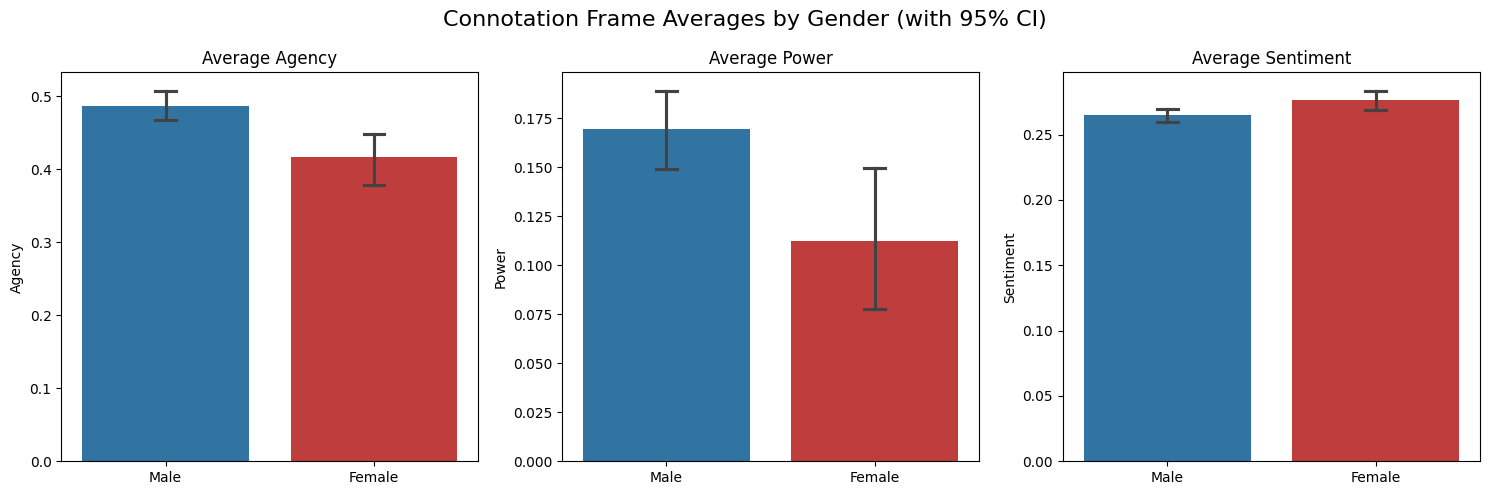

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 1. Separate the data
female_data = analysis_df[analysis_df['Assigned_Gender'] == 'Female']
male_data = analysis_df[analysis_df['Assigned_Gender'] == 'Male']

print("=== STATISTICAL SIGNIFICANCE (T-TESTS) ===")
for metric in ['Agency', 'Power', 'Sentiment']:
    # Drop NaNs for the specific metric
    f_scores = female_data[metric].dropna()
    m_scores = male_data[metric].dropna()
    
    t_stat, p_val = ttest_ind(f_scores, m_scores, equal_var=False)
    
    # Check if the difference is significant
    sig = "*** SIGNIFICANT ***" if p_val < 0.05 else "Not Significant"
    print(f"{metric}: p-value = {p_val:.4f} -> {sig}")

# 2. Plotting with Confidence Intervals
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Connotation Frame Averages by Gender (with 95% CI)', fontsize=16)

metrics = ['Agency', 'Power', 'Sentiment']
colors = {'Male': '#1f77b4', 'Female': '#d62728'}

for i, metric in enumerate(metrics):
    sns.barplot(
        data=analysis_df, 
        x='Assigned_Gender', 
        y=metric, 
        palette=colors, 
        ax=axes[i], 
        capsize=0.1
    )
    axes[i].set_title(f'Average {metric}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('../../data/snippets/cf_metrics_plot.png', dpi=150)
plt.show()

All three metrics being statistically significant (p < 0.05)!

### A Closer Look at the Verbs
What verbs are driving these scores for each gender?

In [20]:
from collections import Counter

male_high_power = Counter()
male_low_power = Counter()
female_high_power = Counter()
female_low_power = Counter()

male_high_agency = Counter()
male_low_agency = Counter()
female_high_agency = Counter()
female_low_agency = Counter()

male_pos_sentiment = Counter()
male_neg_sentiment = Counter()
female_pos_sentiment = Counter()
female_neg_sentiment = Counter()

total_male_actions = 0
total_female_actions = 0

print("Extracting all verbs for Power, Agency & Sentiment...")
for idx, row in df.iterrows():
    text = str(row['Snippet'])
    target_gender = row['Assigned_Gender']
    if target_gender not in ['Male', 'Female']: continue
        
    doc = nlp(text)
    vocab = FEMALE_VOCAB if target_gender == 'Female' else MALE_VOCAB
    
    for token in doc:
        if token.text.lower() in vocab:
            head = token.head
            if head.pos_ == 'VERB':
                verb = head.lemma_.lower()
                role = None
                if token.dep_ in ['nsubj', 'nsubjpass']: role = 'agent'
                elif token.dep_ in ['dobj', 'pobj', 'dative']: role = 'theme'
                
                if role:
                    if target_gender == 'Male': total_male_actions += 1
                    else: total_female_actions += 1

                if role and verb in ap_dict:
                    # Power
                    power = get_power_score(ap_dict[verb].get('power'), role)
                    if pd.notna(power):
                        if power > 0:
                            if target_gender == 'Male': male_high_power[verb] += 1
                            else: female_high_power[verb] += 1
                        elif power < 0:
                            if target_gender == 'Male': male_low_power[verb] += 1
                            else: female_low_power[verb] += 1
                            
                    # Agency (Agency is only assigned to the Agent)
                    if role == 'agent':
                        agency = get_agency_score(ap_dict[verb].get('agency'))
                        if pd.notna(agency):
                            if agency > 0:
                                if target_gender == 'Male': male_high_agency[verb] += 1
                                else: female_high_agency[verb] += 1
                            elif agency < 0:
                                if target_gender == 'Male': male_low_agency[verb] += 1
                                else: female_low_agency[verb] += 1
                            
                if role and verb in sentiment_dict:
                    sent_key = 'writer_perspective(a)' if role == 'agent' else 'writer_perspective(t)'
                    sentiment = sentiment_dict[verb].get(sent_key)
                    if pd.notna(sentiment):
                        if sentiment > 0:
                            if target_gender == 'Male': male_pos_sentiment[verb] += 1
                            else: female_pos_sentiment[verb] += 1
                        elif sentiment < 0:
                            if target_gender == 'Male': male_neg_sentiment[verb] += 1
                            else: female_neg_sentiment[verb] += 1
                            
print("Done!")
print(f"Total extracted male actions: {total_male_actions}")
print(f"Total extracted female actions: {total_female_actions}")

Extracting all verbs for Power, Agency & Sentiment...
Done!


Again we care more about the distinctive male- and female-skewed perspectives instead of the raw distribution (where there's a lot of overlap in common words like 'say', 'know' etc) -> we extract and observe the divergence at the two ends (most positive and most negative) of each of the three connotation spectrum

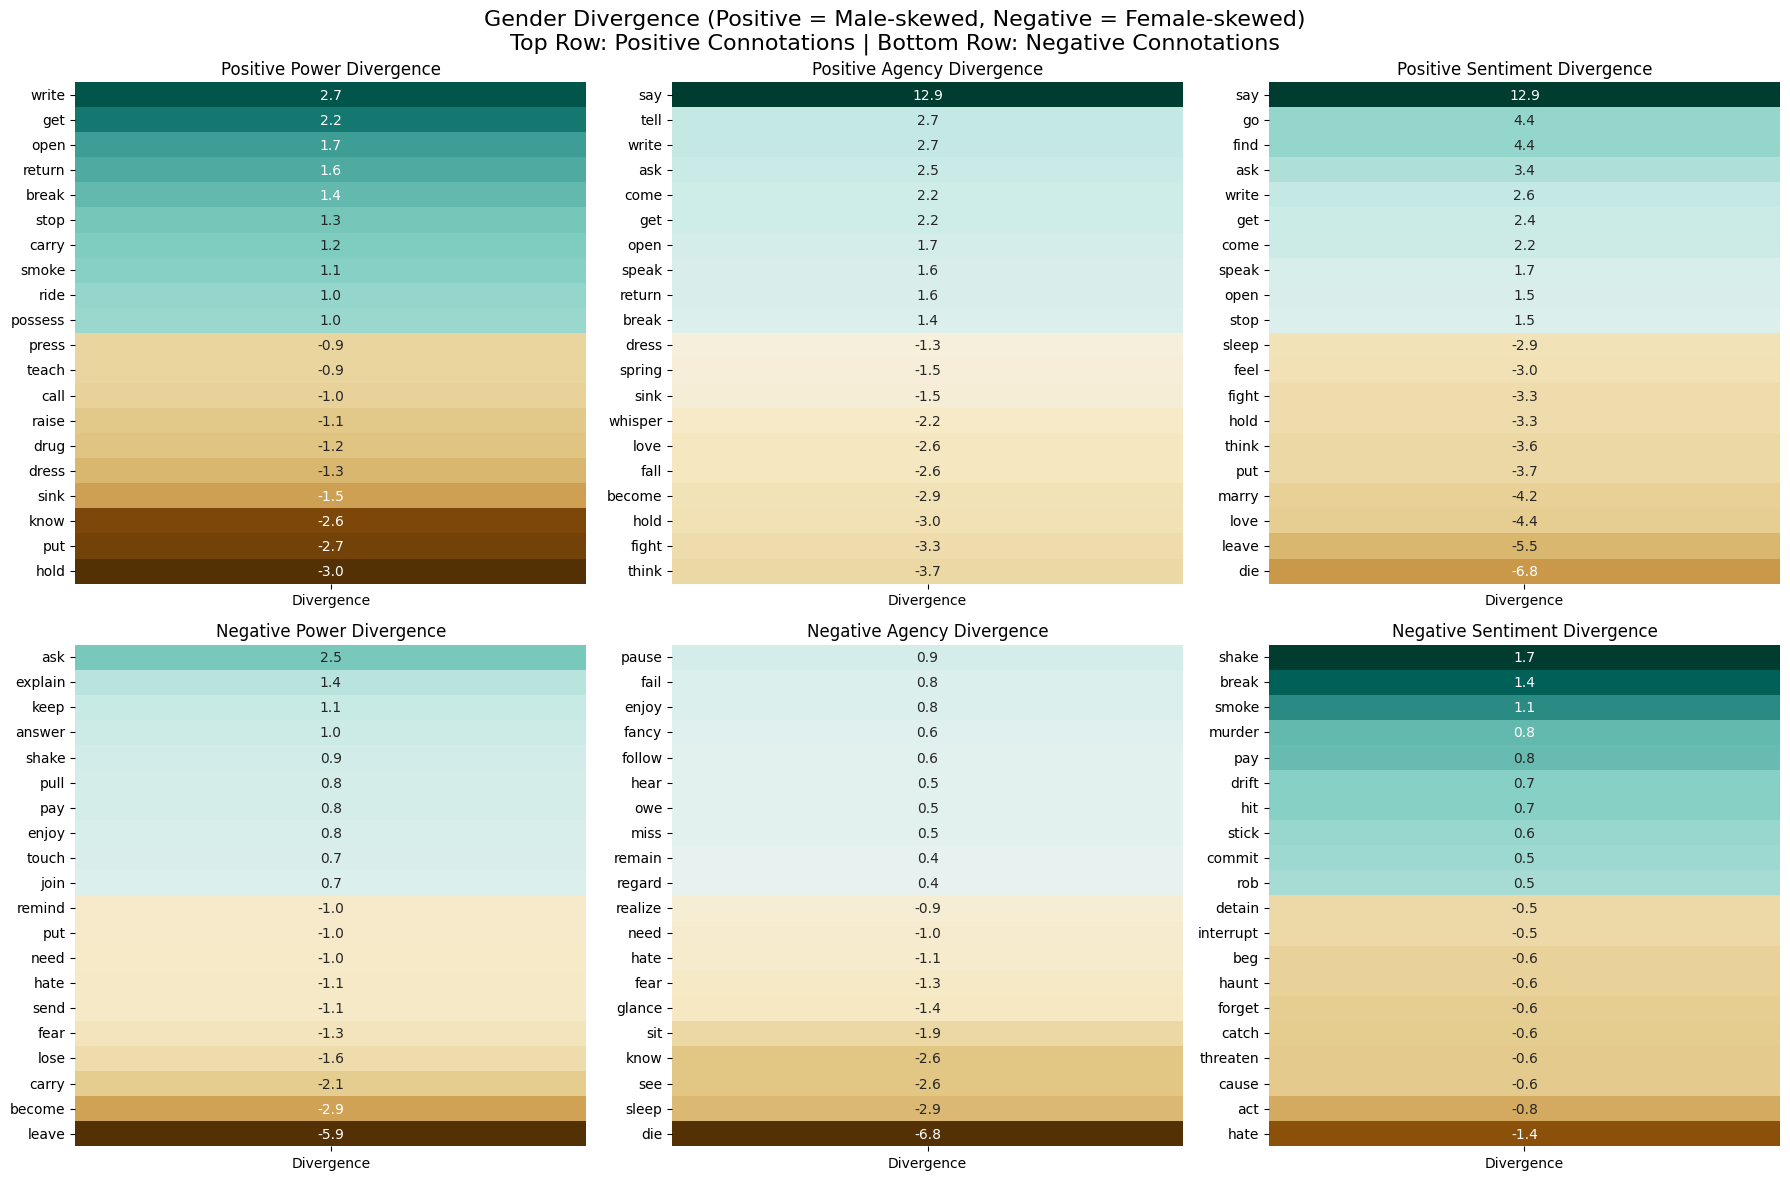

In [20]:
def calculate_divergence_split(male_counter, female_counter, total_male, total_female):
    all_verbs = set(male_counter.keys()).union(set(female_counter.keys()))
    divergence = {}
    for v in all_verbs:
        male_freq = male_counter[v] / total_male * 1000 if total_male > 0 else 0
        female_freq = female_counter[v] / total_female * 1000 if total_female > 0 else 0
        
        if male_freq > 0.5 or female_freq > 0.5:
            # Positive means more Male-skewed, Negative means more Female-skewed
            divergence[v] = male_freq - female_freq
    return divergence

def plot_divergence_split(divergence_dict, title, ax, n=10):
    sorted_verbs = sorted(divergence_dict.items(), key=lambda x: x[1], reverse=True)
    
    if len(sorted_verbs) > 2 * n:
        selected_verbs = [v for v, s in sorted_verbs[:n]] + [v for v, s in sorted_verbs[-n:]]
    else:
        selected_verbs = [v for v, s in sorted_verbs]
        
    counts = [divergence_dict[v] for v in selected_verbs]
    df_plot = pd.DataFrame({'Divergence': counts}, index=selected_verbs)
    
    sns.heatmap(df_plot, annot=True, cmap='BrBG', center=0, cbar=False, fmt='.1f', ax=ax)
    ax.set_title(title)
    ax.set_ylabel('')

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Gender Divergence (Positive = Male-skewed, Negative = Female-skewed)\nTop Row: Positive Connotations | Bottom Row: Negative Connotations', fontsize=16)

# Positive Drivers
plot_divergence_split(calculate_divergence_split(male_high_power, female_high_power, total_male_actions, total_female_actions), 'Positive Power Divergence', axes[0, 0])
plot_divergence_split(calculate_divergence_split(male_high_agency, female_high_agency, total_male_actions, total_female_actions), 'Positive Agency Divergence', axes[0, 1])
plot_divergence_split(calculate_divergence_split(male_pos_sentiment, female_pos_sentiment, total_male_actions, total_female_actions), 'Positive Sentiment Divergence', axes[0, 2])

# Negative Drivers
plot_divergence_split(calculate_divergence_split(male_low_power, female_low_power, total_male_actions, total_female_actions), 'Negative Power Divergence', axes[1, 0])
plot_divergence_split(calculate_divergence_split(male_low_agency, female_low_agency, total_male_actions, total_female_actions), 'Negative Agency Divergence', axes[1, 1])
plot_divergence_split(calculate_divergence_split(male_neg_sentiment, female_neg_sentiment, total_male_actions, total_female_actions), 'Negative Sentiment Divergence', axes[1, 2])

plt.tight_layout()
plt.savefig('../../data/snippets/cf_divergence_split.png', dpi=150)
plt.show()

Observation:
1. Power Divergence
* Positive Power:
    * Male-skewed (Teal/Top): Verbs like write, get, open, possess, and smoke
    * Female-skewed (Brown/Bottom): Verbs like teach, raise, hold, and drug

    &rarr; Interpretation: Men dominate active physical control and possession. Crucially, smoke is skewed toward male positive power, showing that the physical act of consuming opium is a male-dominated locus of power. Meanwhile, women are associated with domestic/relational care (teach, raise, hold) and drug—suggesting the archetype of women either administering drugs as caretakers or being the instruments of seduction/drugging.

* Negative Power:
    * Male-skewed: ask, explain, answer, pay
    * Female-skewed: need, fear, become, and leave

    &rarr; Interpretation: Even when losing power, men remain conversational/transactional agents (asking, explaining, paying). Women, however, are highly vulnerable (need, fear, become) and are heavily characterized by leave—reflecting a tragic trope of women having to flee, abandon, or be abandoned in these opium narratives.

2. Agency Divergence
* Positive Agency:
    * Male-skewed: say, tell, speak
    * Female-skewed: whisper, love, fight, think

    &rarr; Interpretation: Dialogue is heavily gendered. Men are the overt storytellers and authority figures who speak aloud (say, tell, speak). Women have agency primarily in internal cognitive/emotional spaces (think, love, fight) or hushed, secretive communication (whisper).

* Negative Agency:
    * Male-skewed: pause, fail, enjoy, remain
    * Female-skewed: sleep, die

    &rarr; Interpretation: The massive spike in die and sleep for female characters is highly symptomatic of 19th-century opium literature. It points directly to the "tragic, sleeping/dying female victim" archetype—women who are passive victims of opium/laudanum overdoses, remaining entirely powerless as they succumb to sleep and death.

3. Sentiment Divergence
* Positive Sentiment:
    * Male-skewed: say, go, find, get
    * Female-skewed: marry, love, leave, die

    &rarr; Interpretation: Why is die strongly female-skewed in positive sentiment? This mathematically captures the romanticization/aestheticization of female tragedy and death so common in Victorian and fin-de-siècle literature (the "beautiful dying woman" trope).
* Negative Sentiment:
    * Male-skewed: smoke, murder, rob, hit, commit
    * Female-skewed: hate, threaten, beg

    &rarr; Interpretation: Men are associated with violent, transgressive, and criminal negative sentiment (murder, rob, commit a crime/suicide) alongside smoke (marking smoking opium as a transgressive negative act). Women's negative sentiment is internal or pleading (hate, beg).


# Qualitative Spot Checking
Let's take a closer look at a few interesting cases?

In [24]:
from IPython.display import display, HTML
import sys
sys.path.append('../../code')
from utils.constants import KEYWORDS

def show_contexts(target_verb, target_gender, target_role='agent', num_samples=5):
    count = 0
    vocab = FEMALE_VOCAB if target_gender == 'Female' else MALE_VOCAB
    
    html = f"<h3 style='margin-bottom: 5px;'>Contexts for <b>{target_gender}</b> as <b>{target_role}</b> of <i>'{target_verb}'</i></h3>"
    html += "<table style='text-align: left; width: 100%; border-collapse: collapse;'>"
    html += "<tr style='border-bottom: 2px solid black;'><th style='padding: 8px;'>Pronoun</th><th style='padding: 8px;'>Context Snippet</th></tr>"
    
    # We iterate over snippets assigned to the target gender
    for text in df[df['Assigned_Gender'] == target_gender]['Snippet'].dropna():
        doc = nlp(text)
        for token in doc:
            if token.text.lower() in vocab:
                head = token.head
                if head.pos_ == 'VERB' and head.lemma_.lower() == target_verb:
                    
                    role = None
                    if token.dep_ in ['nsubj', 'nsubjpass']: role = 'agent'
                    elif token.dep_ in ['dobj', 'pobj', 'dative']: role = 'theme'
                        
                    if role == target_role:
                        # Rebuild the string with HTML highlights
                        words = []
                        for t in doc:
                            # Check if the token is an opium keyword
                            is_keyword = t.text.lower() in KEYWORDS or t.lemma_.lower() in KEYWORDS
                            
                            if t == token:
                                words.append(f"<b style='color: blue;'>{t.text}</b>" + t.whitespace_)
                            elif t == head:
                                words.append(f"<b style='color: red;'>{t.text}</b>" + t.whitespace_)
                            elif is_keyword:
                                words.append(f"<b style='color: green; background-color: #e6ffe6; padding: 2px;'>{t.text}</b>" + t.whitespace_)
                            else:
                                words.append(t.text_with_ws)
                        highlighted_text = "".join(words)
                        
                        html += f"<tr style='border-bottom: 1px solid #ddd;'>"
                        html += f"<td style='padding: 8px; vertical-align: top; width: 10%;'><b>{token.text}</b></td>"
                        html += f"<td style='padding: 8px;'>{highlighted_text}</td>"
                        html += "</tr>"
                        
                        count += 1
                        if count >= num_samples:
                            break
        if count >= num_samples:
            break
            
    html += "</table>"
    if count == 0:
        html += "<p><i>No examples found.</i></p>"
        
    display(HTML(html))

* The Opium Locus: smoke (Male Transgression) vs. drug (Female Power)

In [21]:
# Why do men smoke with negative sentiment, but positive power?
show_contexts('smoke', 'Male', 'agent')

# How are women "drugging" or being "drugged"?
show_contexts('drug', 'Female', 'agent')
show_contexts('drug', 'Female', 'theme')

Pronoun,Context Snippet
he,"the only safe place, with the coolies of his employer. He must have been in such abject terror that he has almost smoked himself to death.” “But why should the Chinaman shoot my sister?” asked Walker Curtis amazed at the turn of events. “Your sister,” replied Craig, almost reverently, “wrecked though she was by the drug, was at last conscience stricken when she saw the vast plot to debauch thousands of others. It was from her that the Japanese detective in the revenue service got his information—and both of them have paid the price. But they have smashed the new opium ring—we have captured the ring-leaders of the gang.” Out of the maze of streets, on Chatham Square again, we lost no time in mounting to the safety of the elevated station before some murderous tong member might seek revenge on us. The celebration in Chinatown was stilled. It was as though the nerves of the place had been paralysed by our sudden, sharp blow. A downtown train took me to the office to write a “beat,” for the Star always made a special feature of the picturesque in Chinatown news. Kennedy went uptown. Except for a few moments in the"
he,"that he had promised himself to throw away the remainder of the opium on this and succeeding nights. In view of that his movements were inexplicable: he got out from a locked chest the _yen tsiang_, a heavy tube of dark wood inlaid with silver ideograms and diminutive earthen cup at one end. Then he produced a small brass lamp, brushes, long needles, and a metal rod. Taking off his clothes, and in the somber black folds of the silk robe, he made various minutely careful preparations. Finally, extended on his bed, he dipped the end of the rod into opium the color of tar, kept it for a bubbling moment near the blaze of the lamp, and then crowded the drug into the pipe. He held the bowl to the flame and drew in a long deep inhalation. A second followed and the pipe was empty. He repeated this until he had smoked a mace. A vivacious and brilliant state of being flooded him; he felt capable of profoundly witty conversation, and laughed at the solemn absurdities of the Ammidons, at his father attempting to call down a blessing out of the empty sky upon their food, at his sister's"
he,"chambers. On the night of the fourteenth instant, the light was burning until past one o'clock, but it was in the bedroom. The light in the sitting-room was out by ten o'clock.' ""We now come to John Blackmore's evidence. He says: ""'I have viewed the body of the deceased and recognize it as that of my brother Jeffrey. I last saw him alive on the twenty-third of February, when I called at his chambers. He then seemed in a very despondent state of mind and told me that his eyesight was fast failing. I was aware that he occasionally smoked opium , but I did not know that it was a confirmed habit. I urged him, on several occasions, to abandon the practice. I have no reason to believe that his affairs were in any way embarrassed or that he had any reason for making away with himself other than his failing eyesight; but, having regard to his state of mind when I last saw him, I am not surprised at what has happened.' ""That is the substance of John Blackmore's evidence, and, as to Mr. Stephen, his statement merely sets forth the fact that he had identified the body as"
He,"to where he would turn in the wilderness for the commodity he so confidently mentioned. Then, the anguish returning, she checked his motion to depart. ""No, no, Peter,"" she said, commanding her voice with difficulty. ""There is no need for that. I am quite all right. But--but--tell me more! How did this happen? Why did he sleep on the mountain?"" ""How should the _mem-sahib's_ servant know?"" questioned Peter, gently and deferentially, as one who reasoned with a child. ""It may be that the opium of his cigar was stronger than usual. But how can I tell?"" ""Opium! He never smoked opium !"" Stella gazed upon him in fresh bewilderment. ""Surely--surely

Pronoun,Context Snippet
She,"room. ""They've gone, Mr. Holmes. They went by the last train. The lady broke away, and I've got her in a cab downstairs."" ""Excellent, Warner!"" cried Holmes, springing to his feet. ""Watson, the gaps are closing rapidly."" In the cab was a woman, half-collapsed from nervous exhaustion. She bore upon her aquiline and emaciated face the traces of some recent tragedy. Her head hung listlessly upon her breast, but as she raised it and turned her dull eyes upon us I saw that her pupils were dark dots in the centre of the broad gray iris. She was drugged with opium . ""I watched at the gate, same as you advised, Mr. Holmes,"" said our emissary, the discharged gardener. ""When the carriage came out I followed it to the station. She was like one walking in her sleep, but when they tried to get her into the train she came to life and struggled. They pushed her into the carriage. She fought her way out again. I took her part, got her into a cab, and here we are. I shan't forget the face at the carriage window as I led her away. I'd have a short life if he had"
She,"room. “They’ve gone, Mr. Holmes. They went by the last train. The lady broke away, and I’ve got her in a cab downstairs.” “Excellent, Warner!” cried Holmes, springing to his feet. “Watson, the gaps are closing rapidly.” In the cab was a woman, half-collapsed from nervous exhaustion. She bore upon her aquiline and emaciated face the traces of some recent tragedy. Her head hung listlessly upon her breast, but as she raised it and turned her dull eyes upon us I saw that her pupils were dark dots in the centre of the broad grey iris. She was drugged with opium . “I watched at the gate, same as you advised, Mr. Holmes,” said our emissary, the discharged gardener. “When the carriage came out I followed it to the station. She was like one walking in her sleep, but when they tried to get her into the train she came to life and struggled. They pushed her into the carriage. She fought her way out again. I took her part, got her into a cab, and here we are. I shan’t forget the face at the carriage window as I led her away. I’d have a short life if he had"
she,"it was sheer African devilry."" In a flash of thought, I remembered the cup of coffee at Seymour Crescent, the curious sherry at Port-au-Prince, the cigarette with the manchineal she had given me on the mountains, and I saw forthwith that Irene with her woman's quickness had divined rightly. It was more than infatuation; it was intoxication with African charms and West Indian poisons. ""What a man does in such a woman's hands is not his own doing,"" Irene said slowly. ""He has no more control of himself in such circumstances than if she had drugged him with chloroform or opium ."" ""Then you forgive me, Irene?"" ""I have nothing to forgive, Harry. I am grieved for you. I am frightened."" Then bursting into tears, ""My darling, my darling; I love you, I love you!"" _LUCRETIA._ I will acknowledge that I was certainly a very young man in the year '67; indeed, I was only just turned of twenty, and was inordinately proud of a slight downy fringe on my upper lip, which I was pleased to speak of as my moustache. Still, I was a sturdy young fellow enough, in spite of my consumptive tendencies, and not given to groundless"
She,"called, in another direction it had a curious and unlooked-for effect. As if in response to an appeal which had been made directly to herself, Miss Casata, on the opposite side of the bed, sat up. The girls clung to each other in startled terror. To them, for the moment, it was as if she had risen from the dead. Although she had sat up, Miss Casata herself did not seem to know exactly why. She seemed not only stupid, but a little stupefied, and gasped for breath, her respirations resembling convulsions as she struggled with the after-effects of the narcotic . The two girls observed her with amazement, she, on her part, evidently not realising their presence in the least. It was Miss B

Pronoun,Context Snippet
her,"her shaking limbs closer and closer against the man's own pulsating body. She writhed in his arms as he crushed her to him in a sudden access of possessive passion. His head bent slowly down to her, his eyes burned deeper, and, held immovable, she endured the first kiss she had ever received. And the touch of his scorching lips, the clasp of his arms, the close union with his warm, strong body robbed her of all strength, of all power of resistance. With a great sob her eyes closed wearily, the hot mouth pressed on hers was like a narcotic , drugging her almost into insensibility. Numbly she felt him gather her high up into his arms, his lips still clinging closely, and carry her across the tent through curtains into an adjoining room. He laid her down on soft cushions. ""Do not make me wait too long,"" he whispered, and left her. And the whispered words sent a shock through her that seemed to wrench her deadened nerves apart, galvanising her into sudden strength. She sprang up with wild, despairing eyes, and hands clenched frantically across her heaving breast; then, with a bitter cry, she dropped on to the"


* The Victim(?) Archetype: `die` & `sleep` under Negative Female-Skewed Agency

In [22]:
# Inspect the romanticized and passive death of female characters
show_contexts('die', 'Female', 'agent')

# Inspect the passive slumber/opium dreams of female characters
show_contexts('sleep', 'Female', 'agent')

Pronoun,Context Snippet
wife,"Who hold Zam-Zammah, that “fire-breathing dragon”, hold the Punjab, for the great green-bronze piece is always first of the conqueror’s loot. There was some justification for Kim—he had kicked Lala Dinanath’s boy off the trunnions—since the English held the Punjab and Kim was English. Though he was burned black as any native; though he spoke the vernacular by preference, and his mother-tongue in a clipped uncertain sing-song; though he consorted on terms of perfect equality with the small boys of the bazar; Kim was white—a poor white of the very poorest. The half-caste woman who looked after him (she smoked opium , and pretended to keep a second-hand furniture shop by the square where the cheap cabs wait) told the missionaries that she was Kim’s mother’s sister; but his mother had been nursemaid in a Colonel’s family and had married Kimball O’Hara, a young colour-sergeant of the Mavericks, an Irish regiment. He afterwards took a post on the Sind, Punjab, and Delhi Railway, and his Regiment went home without him. The wife died of cholera in Ferozepore, and O’Hara fell to drink and loafing up and down the line with the keen-eyed three-year-old baby. Societies and chaplains, anxious for the child,"
she,"at twelve-thirty?” Rap! rap! rap! came the faint reply from the cabinet. Or rather it seemed to me to come from the floor near the cabinet, and perhaps to be a trifle muffled by the black carpet. “Are you in communication with Mrs. Vandam?” Rap! rap! rap! “Can she be made to rap for us?” Rap! rap! “Will you ask her a question and spell out her answer?” Rap! rap! rap! Craig paused a moment to frame the question, then shot it out point-blank: “Does Mrs. Vandam know now in the other world whether anyone in this room substituted a morphine capsule for one of those ordered by her three days before she died? Does she know whether the same person has done the same thing with those later ordered by Mr. Vandam?” “John” seemed considerably perturbed at the mention of capsules. It was a long time before any answer was forthcoming. Kennedy was about to repeat the question when a faint sound was heard. Rap!---- Suddenly came a wild scream. It was such a scream as I had never heard before in my life. It came as though a dagger had been thrust into the heart of Mrs. Popper. The"
she,"there is no reason to suppose that any poison has been administered in this case, as I, of course, go by what I see; and the presence of poisons, especially vegetable poisons, can only be detected by chemical analysis. Q. Did you analyse the contents of the stomach chemically? A. No; it was not my duty to do so; I handed over the stomach to the police, seeing that there is suspicion of poison, and thence it will go to the Government analyst. Q. It is stated that the deceased had convulsions before she died--is this not a symptom of narcotic poisoning? A. In some cases, yes, but not commonly; aconite, for instance, always produces convulsions in animals, seldom in man. Q. How do you account for the congested condition of the lungs? A. I believe the serous effusion caused death by suspended respiration. Q. Was there any odour perceptible? A. No, none whatsoever. The inquest was then adjourned till next day, and there was great excitement over the affair. If Kitty Marchurst’s statement was true, the deceased must have died from the administration of poison; but, on the other hand, Dr Chinston asserted positively that there was no trace of"
wife,"immediately. Now that you know Nettie's safe you must control yourself. No one should go up--keep everybody out--till you hear from me or the doctor or Captain Ammidon."" What an inexplicable accident or crime, he thought, hurriedly approaching the countinghouse of Ammidon, Ammidon and Saltonstone, the first and nearest of the places to which he must go. He could remember no mark of what had overcome Taou Yuen. How was Dunsack, who was now clearly demented, implicated? What racking thing had Nettie

Pronoun,Context Snippet
she,"that all this effect on her nervous system, which evidently involved some new turning towards himself, was due to the excitement of the new impressions which that visit had raised. CHAPTER LXXIX. “Now, I saw in my dream, that just as they had ended their talk, they drew nigh to a very miry slough, that was in the midst of the plain; and they, being heedless, did both fall suddenly into the bog. The name of the slough was Despond.”—BUNYAN. When Rosamond was quiet, and Lydgate had left her, hoping that she might soon sleep under the effect of an anodyne , he went into the drawing-room to fetch a book which he had left there, meaning to spend the evening in his work-room, and he saw on the table Dorothea’s letter addressed to him. He had not ventured to ask Rosamond if Mrs. Casaubon had called, but the reading of this letter assured him of the fact, for Dorothea mentioned that it was to be carried by herself. When Will Ladislaw came in a little later Lydgate met him with a surprise which made it clear that he had not been told of the earlier visit, and Will could not"
She,"of infidelity, and realizes the significance of the act without being wholly awakened from its glamour. The thought was passing vaguely through her mind, “What would he think?” She did not mean her husband; she was thinking of Robert Lebrun. Her husband seemed to her now like a person whom she had married without love as an excuse. She lit a candle and went up to her room. Alcée Arobin was absolutely nothing to her. Yet his presence, his manners, the warmth of his glances, and above all the touch of his lips upon her hand had acted like a narcotic upon her. She slept a languorous sleep, interwoven with vanishing dreams. XXVI Alcée Arobin wrote Edna an elaborate note of apology, palpitant with sincerity. It embarrassed her; for in a cooler, quieter moment it appeared to her absurd that she should have taken his action so seriously, so dramatically. She felt sure that the significance of the whole occurrence had lain in her own self-consciousness. If she ignored his note it would give undue importance to a trivial affair. If she replied to it in a serious spirit it would still leave in his mind the impression that she had"
she,"shame Blew trumpet in the lists. And so she trod the poppies there, Remembering other poppies, too, And did not seem to see or care. Without, the first gray drops of dew Sweetened the trembling air. She trod the poppies. Hours passed Until she slept at length -- and Time Dragged his slow sickle. When at last She woke, the moon shone, bright as rime, And night's tide rolled on fast. She moaned once, knowing everything; Then, bitterer than death, she found The soft handmaidens, in a ring, Come to anoint her, all around, That she might please the king. Opium -- and the odor dies away, Leaving the air yet heavy -- cassia -- myrrh -- Bitter and splendid. See, the poisons come, Trooping in squat green vials, blazoned red With grinning skulls: strychnine, a pallid dust Of tiny grains, like bones ground fine; and next The muddy green of arsenic, all livid, Likest the face of one long dead -- they creep Along the dusty shelf like deadly beetles, Whose fangs are carved with runnels, that the blood May run down easily to the blind mouth That snaps and gapes; and high above them there, My master's pride, a"
she,"her with many sighs, but Josephine smiled. Rose eyed her with suspicion. That deep smile; what did it mean? She had formed some resolution. “She is going to deceive me somehow,” thought Rose. From that day she watched Josephine like a spy. Confidence was gone between them. Suspicion took its place. Rose was right in her misgivings. The moment Josephine saw that Edouard’s happiness and Rose’s were to be sacrificed for her whom nothing could make happy, the poor thing said to herself, “I CAN DIE.” And that was the happy thought that made her smile. The doctor gave her laudanum : he found she could not sleep: and he t

* Dialogue vs. Secrets: say (Male) vs. whisper (Female)

In [23]:
# Look at what male characters actively dictate or declare
show_contexts('say', 'Male', 'agent')

# Look at the conspiratorial or submissive nature of female whispering
show_contexts('whisper', 'Female', 'agent')


Pronoun,Context Snippet
He,"of gambling in Paris, watching it as if it had been a disease. He was no more tempted by such winning than he was by drink. He had said to himself that the only winning he cared for must be attained by a conscious process of high, difficult combination tending towards a beneficent result. The power he longed for could not be represented by agitated fingers clutching a heap of coin, or by the half-barbarous, half-idiotic triumph in the eyes of a man who sweeps within his arms the ventures of twenty chapfallen companions. But just as he had tried opium , so his thought now began to turn upon gambling—not with appetite for its excitement, but with a sort of wistful inward gaze after that easy way of getting money, which implied no asking and brought no responsibility. If he had been in London or Paris at that time, it is probable that such thoughts, seconded by opportunity, would have taken him into a gambling-house, no longer to watch the gamblers, but to watch with them in kindred eagerness. Repugnance would have been surmounted by the immense need to win, if chance would be kind enough to let him. An"
He,"at the persistent life in this man, whom he would fain have seen sinking into the silence of death: imperious will stirred murderous impulses towards this brute life, over which will, by itself, had no power. He said inwardly that he was getting too much worn; he would not sit up with the patient to-night, but leave him to Mrs. Abel, who, if necessary, could call her husband. At six o’clock, Raffles, having had only fitful perturbed snatches of sleep, from which he waked with fresh restlessness and perpetual cries that he was sinking away, Bulstrode began to administer the opium according to Lydgate’s directions. At the end of half an hour or more he called Mrs. Abel and told her that he found himself unfit for further watching. He must now consign the patient to her care; and he proceeded to repeat to her Lydgate’s directions as to the quantity of each dose. Mrs. Abel had not before known anything of Lydgate’s prescriptions; she had simply prepared and brought whatever Bulstrode ordered, and had done what he pointed out to her. She began now to ask what else she should do besides administering the opium. “Nothing at present, except the"
he,"towards Raffles’s room, and he could hear him moaning and murmuring. He was not asleep, then. Who could know that Lydgate’s prescription would not be better disobeyed than followed, since there was still no sleep? He turned into his own room. Before he had quite undressed, Mrs. Abel rapped at the door; he opened it an inch, so that he could hear her speak low. “If you please, sir, should I have no brandy nor nothing to give the poor creetur? He feels sinking away, and nothing else will he swaller—and but little strength in it, if he did—only the opium . And he says more and more he’s sinking down through the earth.” To her surprise, Mr. Bulstrode did not answer. A struggle was going on within him. “I think he must die for want o’ support, if he goes on in that way. When I nursed my poor master, Mr. Robisson, I had to give him port-wine and brandy constant, and a big glass at a time,” added Mrs. Abel, with a touch of remonstrance in her tone. But again Mr. Bulstrode did not answer immediately, and she continued, “It’s not a time to spare when people are at"
he,"unreservedly as I have told it in these pages. He started to his feet, and looked at me with breathless eagerness as I approached the leading incident of my story. “It is certain that I went into the room,” I said; “it is certain that I took the Diamond. I can only meet those two plain facts by declaring that, do what I might, I did it without my own knowledge——” Ezra Jennings caught me excitedly by the arm. “Stop!” he said. “You have suggested more to me than you suppose. Have _you_ ever been accustomed to the use of opium ?” “I never tasted it in my life.” “Were your nerves out of order, at this time la

Pronoun,Context Snippet
she,"six or seven hours, at least. It is some distance to carry him back to his own room. When I was younger, I could have done it alone. But my health and strength are not what they were—I am afraid I must ask you to help me.” Before they could answer, Miss Verinder called to me softly. She met me at the door of her room, with a light shawl, and with the counterpane from her own bed. “Do you mean to watch him while he sleeps?” she asked. “Yes, I am not sure enough of the action of the opium in his case to be willing to leave him alone.” She handed me the shawl and the counterpane. “Why should you disturb him?” she whispered. “Make his bed on the sofa. I can shut my door, and keep in my room.” It was infinitely the simplest and the safest way of disposing of him for the night. I mentioned the suggestion to Mr. Bruff and Betteredge—who both approved of my adopting it. In five minutes I had laid him comfortably on the sofa, and had covered him lightly with the counterpane and the shawl. Miss Verinder wished us good-night, and"
she,"must trouble you to put your papers aside for a moment,” I said. “Oh, certainly!” He got up with a start—as if I had disturbed him at a particularly interesting place—and followed me to the medicine-chest. There, deprived of the breathless excitement incidental to the practice of his profession, he looked at Betteredge—and yawned wearily. Miss Verinder joined me with a glass jug of cold water, which she had taken from a side-table. “Let me pour out the water,” she whispered. “I _must_ have a hand in it!” I measured out the forty minims from the bottle, and poured the laudanum into a medicine glass. “Fill it till it is three parts full,” I said, and handed the glass to Miss Verinder. I then directed Betteredge to lock up the medicine chest; informing him that I had done with it now. A look of unutterable relief overspread the old servant’s countenance. He had evidently suspected me of a medical design on his young lady! After adding the water as I had directed, Miss Verinder seized a moment—while Betteredge was locking the chest, and while Mr. Bruff was looking back to his papers—and slyly kissed the rim of the medicine glass. “When"
woman,"with a familiarity bred of habit. “What a strange woman!” whispered Rita to Pyne. “Is she an oriental?” “Cuban-Jewess,” he replied in a low voice. Mrs. Sin carefully lighted the lamp, which burned with a short, bluish flame, and, opening the lacquered box, she dipped the spatula into the thick gummy substance which it contained and twisted the little instrument round and round between her fingers, presently withdrawing it with a globule of _chandu_, about the size of a bean, adhering to the end. She glanced aside at Kilfane. “Chinese way, eh?” she said. She began to twirl the prepared opium above the flame of the lamp. From it a slight, sickly smelling vapor arose. No one spoke, but all watched her closely; and Rita was conscious of a growing, pleasurable excitement. When by evaporation the _chandu_ had become reduced to the size of a small pea, and a vague spirituous blue flame began to dance round the end of the spatula, Mrs. Sin pressed it adroitly into the tiny bowl of one of the ivory pipes, having first held the bowl inverted for a moment over the lamp. She turned to Rita. “The guest of the evening,” she said. “Do"
she,"expression of mystic rapture like that characterizing the features of some Chinese Buddhas. Fear, unaccountable but uncontrollable, suddenly seized upon Rita. She felt weak and dizzy, but she struggled partly upright. “Lucy!” she whispered. Her voice was not under control, and once more she strove to call to Pyne. “Lucy!” came the hoarse whisper again. The fire continued its muted roaring, but no other sound answered to the appeal. A horror of the companionship in which she found herself thereupon took possession of the girl. She must escape from these sleepers, whose spirits had been expelled by the potent necromancer, 